# Beamline Simulation Tutorial: Scripting with `shadow4`

*Bay Area Light Source Joint User Meeting, 2026*

**Contact:**
- Wei "Francis" He — francisho@lbl.gov
- Dr. Antoine Islegen-Wojdyla — awojdyla@lbl.gov

**Acknowledgements:**

Beamline parameters are taken from the ALS-U COSMIC-U (7.0.1) optical design.

---

## This Notebook: A Plane-Grating Monochromator

A plane mirror followed by a variable-line-spacing (VLS) plane grating: the monochromator of COSMIC-U, with nothing after it. The Oasys export works at one photon energy, 1000 eV. We take it apart as in Part 1, then give it an energy axis and scan the grating's band.

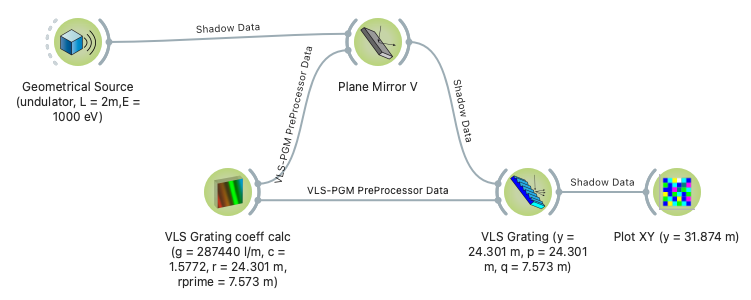

Source → plane mirror → VLS grating, 287 440 lines/m → screen at 31.874 m. The mirror deflects the beam up onto the grating, and the grating deflects it back down, parallel to where it came in.

The *VLS Grating coeff calc* widget feeds both optics: from the grating's line density, its $c_{ff}$ and the distances $r$ and $r'$, it computes the ruling and, for the source energy, the angles and positions of the mirror and the grating.

### Contents

- **0. Setup** — packages and imports.
- **1. The script from Oasys** — the export, unchanged, and what is new with two optics.
- **2. Retrace and plot** — `retrace` and `histo2` are Part 1's; nothing new here.
- **3. Component breakdown** — the source; the grating and its pre-mirror, with the angle solve that places them; rebuilt and checked ray for ray against the paste.
- **4. The energy axis** — what the export does when only the energy changes; the angle solve and the source size as functions of energy; a beamline function that takes the energy as its argument, and a scan across the grating's band.

### Resources

- shadow4 source code and examples: [github.com/oasys-kit/shadow4](https://github.com/oasys-kit/shadow4)
- Oasys: [github.com/oasys-kit](https://github.com/oasys-kit)

## 0. Setup

Same requirements as Part 1, plus `scipy` for the angle solve in Section 3:

```bash
pip install shadow4 srxraylib scipy
```

In [9]:
from importlib.metadata import version

import numpy as np
import matplotlib.pyplot as plt

for pkg in ["shadow4", "syned", "srxraylib", "scipy", "numpy", "matplotlib"]:
    print(f"{pkg:11s} {version(pkg)}")

shadow4     0.1.88
syned       1.0.57
srxraylib   1.0.68
scipy       1.18.0
numpy       2.5.2
matplotlib  3.11.1


## 1. The Script from Oasys

Output of the *Python Script* widget attached to the _Plot XY_ in the canvas above, unchanged.

> __Note:__ On the _Plot XY_ widget, select 'retraced' for 'Position of the image'.

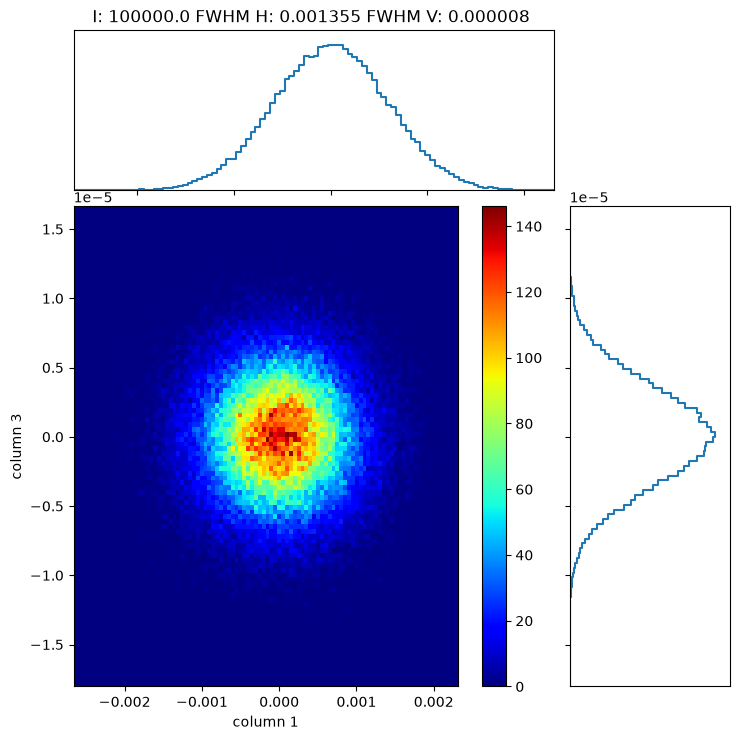

(<Figure size 800x800 with 4 Axes>,
 <Axes: xlabel='column 1', ylabel='column 3'>,
 <Axes: title={'center': 'I: 100000.0 FWHM H: 0.001355 FWHM V: 0.000008 '}>,
 <Axes: >)

In [10]:
import numpy as np

def run_beamline():
    footprint = None
    import numpy as np
    from dabax.dabax_xraylib import DabaxXraylib
    from shadow4.beamline.s4_beamline import S4Beamline
    
    beamline = S4Beamline()
    
    #
    #
    #
    from shadow4.sources.source_geometrical.source_geometrical import SourceGeometrical
    light_source = SourceGeometrical(name='Geometrical Source (undulator, L = 2m,E = 1000 eV)', nrays=100000, seed=12)
    light_source.set_spatial_type_gaussian(sigma_h=1.65e-05,sigma_v=1.84e-05)
    light_source.set_depth_distribution_off()
    light_source.set_angular_distribution_gaussian(sigdix=1.86e-05,sigdiz=1.83e-05)
    light_source.set_energy_distribution_singleline(1000, unit='eV')
    light_source.set_polarization(polarization_degree=1, phase_diff=0, coherent_beam=0)
    beam = light_source.get_beam()
    
    beamline.set_light_source(light_source)
    
    # optical element number XX
    from syned.beamline.shape import Rectangle
    boundary_shape = Rectangle(x_left=-0.008, x_right=0.008, y_bottom=-0.155, y_top=0.155)
       
    from shadow4.beamline.optical_elements.mirrors.s4_plane_mirror import S4PlaneMirror
    optical_element = S4PlaneMirror(name='Plane Mirror V', boundary_shape=boundary_shape,
        f_reflec=0, # reflectivity of surface: 0=no reflectivity, 1=full polarization
        f_refl=0, # for f_reflec=1: file: 0=prerefl, 2=(mrad, refl), 3=(eV, refl), 4=(eV, mrad, refl); 1=refr index, 5=xraylib, 6=dabax
        file_refl='<none>', # for f_refl=0,2,3,4
        refraction_index=0.99999+0.001j, # for f_refl=1
        coating_material='Si', coating_density=2.33, # for f_refl=5,6
        coating_roughness=0, # for f_refl=0,1,5,6
        dabax=None, # if using dabax (f_reflec=1,f_refl=6), instance of DabaxXraylib() (use None for default)
        )
    
    from syned.beamline.element_coordinates import ElementCoordinates
    coordinates = ElementCoordinates(p=24.123903, q=0.0886895, angle_radial=1.54259308, angle_azimuthal=0, angle_radial_out=1.54259308)
    movements = None
    from shadow4.beamline.optical_elements.mirrors.s4_plane_mirror import S4PlaneMirrorElement
    beamline_element = S4PlaneMirrorElement(optical_element=optical_element, coordinates=coordinates, movements=movements, input_beam=beam)
    
    beam, footprint = beamline_element.trace_beam()
    
    beamline.append_beamline_element(beamline_element)
    
    # optical element number XX
    from syned.beamline.shape import Rectangle
    boundary_shape = Rectangle(x_left=-0.01, x_right=0.01, y_bottom=-0.09, y_top=0.09)
    from shadow4.beamline.optical_elements.gratings.s4_plane_grating import S4PlaneGrating
    optical_element = S4PlaneGrating(name='VLS Grating (y = 24.301 m, p = 24.301 m, q = 7.573 m)',
        boundary_shape=None, f_ruling=1, order=-1,
        ruling=287440.0, ruling_coeff_linear=142771.836, 
        ruling_coeff_quadratic=24131.408, ruling_coeff_cubic=4470.25,
        ruling_coeff_quartic=0.0,
        )
    from syned.beamline.element_coordinates import ElementCoordinates
    coordinates = ElementCoordinates(p=0.0886895, q=7.573, angle_radial=1.548912027, angle_azimuthal=3.141592654, angle_radial_out=1.536274133)
    movements = None
    from shadow4.beamline.optical_elements.gratings.s4_plane_grating import S4PlaneGratingElement
    beamline_element = S4PlaneGratingElement(optical_element=optical_element, coordinates=coordinates, movements=movements, input_beam=beam)
    
    beam, footprint = beamline_element.trace_beam()
    
    beamline.append_beamline_element(beamline_element)
    return beam, footprint

#
# main 
#
from srxraylib.plot.gol import plot, plot_image, plot_image_with_histograms, plot_show

# WARNING: NO incremental result allowed!!"
beam, footprint = run_beamline()
beam.retrace(0.000000)

ticket = beam.histo2(1, 3, nbins_h=100, nbins_v=100, xrange=[np.float64(-0.0026856121506562787), np.float64(0.0023337723361302127)], yrange=[np.float64(-1.8206238967370853e-05), np.float64(1.680665247697966e-05)], nolost=1, ref=23)

title = "I: %.1f " % ticket['intensity']
if ticket['fwhm_h'] is not None: title += "FWHM H: %f " % ticket['fwhm_h']
if ticket['fwhm_v'] is not None: title += "FWHM V: %f " % ticket['fwhm_v']

plot_image_with_histograms(ticket['histogram'], ticket['bin_h_center'], ticket['bin_v_center'],
    title=title, xtitle="column 1", ytitle="column 3",
    cmap='jet', add_colorbar=True, figsize=(8, 8), histo_path_flag=1, show=1)


### What is new 

There are two optics rather than one, and the beam returned by the mirror's `trace_beam()` is the `input_beam` of the grating block. 

The two `ElementCoordinates` lines hold everything that sets up the monochromator:

| | Pre-mirror (plane) | VLS grating |
|---|---|---|
| optic | `S4PlaneMirror` | `S4PlaneGrating` |
| `p` | source → mirror | second half of the mirror–grating gap |
| `q` | first half of the mirror–grating gap | grating → focus |
| `angle_radial_out` | equal to `angle_radial` | different: $\beta$ out, $\alpha$ in |

<br>

> __Notes:__
> - **`angle_radial_out` ≠ `angle_radial` on the grating;** rather, they satisfy the grating equation $\sin\alpha - \sin\beta = \lambda g_0$. The pre-mirror is thus set to $(\alpha + \beta)/2$, so that the beam leaves parallel to the one that came in.
> - **Mirror `q` + grating `p`** is the mirror-to-grating distance along the beam, split in two halves — only the sum matters. It is set by the grating's fixed height above the incoming beam (Section 3.2).
> - **These angles and distances hold for 1000 eV only.** The *VLS Grating coeff calc* widget solved for them once, at the source energy, and the export froze them as numbers. At any other energy the grating angles, the mirror angle and both distances have to be recalculated — so to loop over energy, the script needs a helper that does what the widget does: Section 4 builds it.



## 2. Retrace and Plot

`retrace` and `histo2` work exactly as in Part 1.

## 3. Component Breakdown

The same script, one block per cell. The export reuses the names `optical_element` and `coordinates` for both optics; here each gets its own name, so both stay around to inspect. Section 3.3 checks the rebuilt beam against the pasted one.

In [3]:
beam_paste = beam.duplicate()   # keep the pasted script's result for the comparison in 3.3

### 3.1 Source

Same as before ~

In [4]:
from shadow4.sources.source_geometrical.source_geometrical import SourceGeometrical

light_source = SourceGeometrical(name='Geometrical Source (undulator, L = 2m,E = 1000 eV)', nrays=100000, seed=12)
light_source.set_spatial_type_gaussian(sigma_h=1.65e-05, sigma_v=1.84e-05)
light_source.set_depth_distribution_off()
light_source.set_angular_distribution_gaussian(sigdix=1.86e-05, sigdiz=1.83e-05)
light_source.set_energy_distribution_singleline(1000, unit='eV')
light_source.set_polarization(polarization_degree=1, phase_diff=0, coherent_beam=0)
beam = light_source.get_beam()

### 3.2 Monochromator

Our mono is made of a VLS grating and its pre-mirror. The two are one problem: the grating's angles decide how the mirror is tilted and where it sits, so they are built together.

In [5]:
from syned.beamline.shape import Rectangle
from shadow4.beamline.optical_elements.mirrors.s4_plane_mirror import S4PlaneMirror

# --- the pre-mirror: a plane needs no surface parameters, only an aperture
mirror = S4PlaneMirror(name='Plane Mirror V',
    boundary_shape=Rectangle(x_left=-0.008, x_right=0.008, y_bottom=-0.155, y_top=0.155),
    f_reflec=0,
    f_refl=0, file_refl='<none>', refraction_index=0.99999+0.001j,
    coating_material='Si', coating_density=2.33, coating_roughness=0,
    dabax=None,
    )

from shadow4.beamline.optical_elements.gratings.s4_plane_grating import S4PlaneGrating

# --- the grating: flat as well, but ruled
grating = S4PlaneGrating(name='VLS Grating (y = 24.301 m, p = 24.301 m, q = 7.573 m)',
    boundary_shape=None, f_ruling=1, order=-1,
    ruling=287440.0, ruling_coeff_linear=142771.836,
    ruling_coeff_quadratic=24131.408, ruling_coeff_cubic=4470.25,
    ruling_coeff_quartic=0.0,
    )

`S4PlaneMirror` takes only an aperture — 16 mm × 310 mm, written straight into the constructor — and the reflectivity switches, off as in Part 1.

`S4PlaneGrating` is flat too, but ruled. With `f_ruling=1` its line density varies along its length; with $w$ the position along the grating from its centre,

$$g(w) = g_0 + g_1 w + g_2 w^2 + g_3 w^3 .$$

| | argument | value | what it does |
|---|---|---|---|
| $g_0$ [l/m] | `ruling` | 287 440 | sets the dispersion |
| $g_1$ [l/m²] | `ruling_coeff_linear` | 142 771.836 | focuses: puts the image at $r'$ |

$g_2$ and $g_3$ correct higher-order aberrations; the appendix says where all four come from. The coefficients are the ruling of a real grating, so they never change. `order=-1` is the first inside order in shadow4's sign convention.

#### Placement and orientation

`ElementCoordinates` carries the same five numbers as in Part 1, now for two optics:

- **`p`, `q`** — the mirror sits `p` = 24.123903 m from the source, and its `q` plus the grating's `p` make up the 0.177379 m between them. The grating's `q` = 7.573 m reaches the screen.
- **`angle_radial`, `angle_radial_out`** — equal on the mirror, different on the grating ($\alpha$ in, $\beta$ out).
- **`angle_azimuthal`** — 0 on the mirror, which deflects the beam vertically upward, and π on the grating, which sends it back down. The two deflections cancel, so the beam leaves the monochromator parallel to the one that entered.

Every number below is the export's, at 1000 eV. Where they come from is the next part.

In [6]:
from syned.beamline.element_coordinates import ElementCoordinates

# The export's numbers, at 1000 eV. pgm_solve() reproduces them below.
# ElementCoordinates hands its values back through methods: p(), angle_radial().
mirror_coordinates = ElementCoordinates(p=24.123903, q=0.0886895, angle_radial=1.54259308, angle_azimuthal=0, angle_radial_out=1.54259308)
grating_coordinates = ElementCoordinates(p=0.0886895, q=7.573, angle_radial=1.548912027, angle_azimuthal=3.141592654, angle_radial_out=1.536274133)

#### The angles: `pgm_solve()`

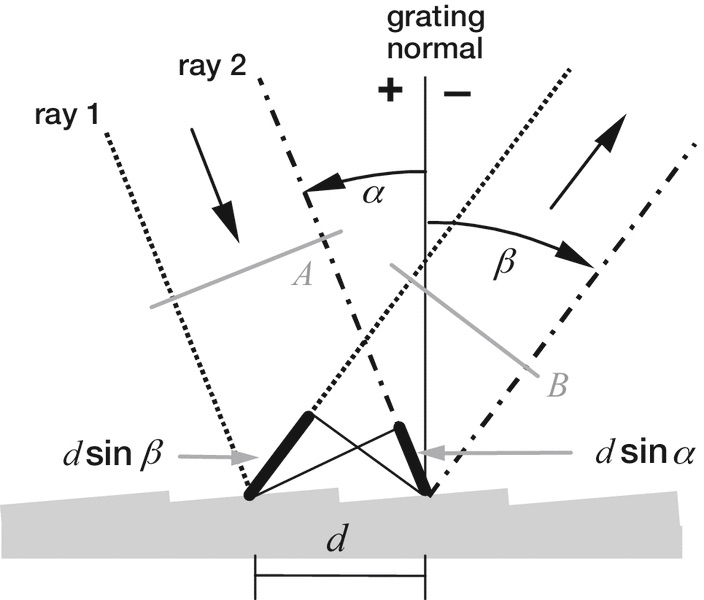

*Figure: Newport Corporation, [The Grating Equation](https://www.newport.com/n/the-grating-equation), technical note. The grating equation, in the usual sign convention: $\alpha$ and $\beta$ are measured from the grating normal and counted positive on opposite sides, and the path difference between neighbouring grooves is $d(\sin\alpha - \sin\beta)$. The drawing shows an outside order. Here the diffracted ray leaves on the **same** side as the incident one — the first inside order, shadow4's `order=-1` — so $\beta$ is positive too and the difference is small.*

__Variables:__
- Fixed: the ruling $g_0$, $g_1$ and the layout — $r$ = 24.301 m source to grating, $r'$ = 7.573 m grating to screen.
- Undetermined: `angle_radial` = $\alpha$ and `angle_radial_out` = $\beta$, both measured from the grating's normal, as shown in the figure above. They depend on the beam wavelength $\lambda = hc/E$.

__Governing equations:__

$$\sin\alpha - \sin\beta = \lambda g_0 \qquad \text{(grating equation)}$$

$$\frac{\cos^2\alpha}{r} + \frac{\cos^2\beta}{r'} = \lambda g_1 \qquad \text{(focus on the screen)}$$

Two equations, two unknowns: `pgm_solve()` below returns $\alpha$ and $\beta$ at any photon energy.

Then the layout of the grating and the pre-mirror follows, with $D = \pi - \alpha - \beta$ the total deflection of the beam:

$$\theta_\text{mirror} = \frac{\alpha + \beta}{2}, \qquad L_{MG} = \frac{\Delta y}{\sin D}, \qquad d_{SM} = r - \frac{\Delta y}{\tan D}$$

where $L_{MG}$ and $d_{SM}$ are the mirror-to-grating and source-to-mirror distances respectively, and $\Delta y$ = 10 mm is the fixed vertical separation between the two optics.

> __Note:__ This is the calculation the *VLS Grating coeff calc* widget does, and the export froze one of its answers. Section 4 calls it at every energy of a scan.

In [7]:
from scipy.optimize import brentq

hc_eVm = 1.239841984e-6                      # h·c [eV·m]
g0_per_m, g1_per_m2 = 287440.0, 142771.836   # this grating's ruling [l/m], [l/m²]
r_m, r_prime_m, dy_m = 24.301, 7.573, 0.010  # source–grating, grating–screen, grating height [m]


# The five numbers above are the defaults, so a different grating is one call away;
# they are also used by the checks and hand estimates in the rest of the notebook.
def pgm_solve(energy_eV, g0_per_m=g0_per_m, g1_per_m2=g1_per_m2,
              r_m=r_m, r_prime_m=r_prime_m, dy_m=dy_m):
    # Angles and distances of the grating and its pre-mirror at one photon energy.
    wavelength_m = hc_eVm / energy_eV
    path_r_m = r_m                            # first guess for r; refined at the end of each pass
    for _ in range(4):
        # The grating equation gives β from α, which leaves the focus condition as one
        # equation in one unknown. It has a single root on [0°, 90°): brentq finds it.
        def focus_residual(a_rad):
            b_rad = np.arcsin(np.sin(a_rad) - wavelength_m * g0_per_m)
            return np.cos(a_rad)**2 / path_r_m + np.cos(b_rad)**2 / r_prime_m - wavelength_m * g1_per_m2
        alpha_rad = brentq(focus_residual, 0.0, np.radians(89.999), xtol=1e-15)
        beta_rad = np.arcsin(np.sin(alpha_rad) - wavelength_m * g0_per_m)

        D_rad = np.pi - alpha_rad - beta_rad  # total deflection, then the layout
        L_MG_m = dy_m / np.sin(D_rad)
        d_SM_m = r_m - dy_m / np.tan(D_rad)
        # r is the path the beam really travels, and the mirror moves with the angles,
        # so feed it back and solve again; it settles by the third pass.
        path_r_m = d_SM_m + L_MG_m

    return {"alpha_rad": alpha_rad, "beta_rad": beta_rad,
            "mirror_rad": (alpha_rad + beta_rad) / 2,    # the mirror's angle_radial
            "d_SM_m": d_SM_m, "L_MG_m": L_MG_m}

At 1000 eV the solve must return what the widget gave the export — and what the widget's *Ray-Tracing Output* shows: α = 88.746122°, β = 88.022024°, source–mirror 24.123903 m, mirror–grating 0.177379 m.

In [8]:
sol = pgm_solve(1000.0)

rows = [("α [deg]",             np.degrees(sol["alpha_rad"]),  np.degrees(grating_coordinates.angle_radial())),
        ("β [deg]",             np.degrees(sol["beta_rad"]),   np.degrees(grating_coordinates.angle_radial_out())),
        ("mirror angle [deg]",  np.degrees(sol["mirror_rad"]), np.degrees(mirror_coordinates.angle_radial())),
        ("d_SM [m]",            sol["d_SM_m"],                 mirror_coordinates.p()),
        ("L_MG [m]",            sol["L_MG_m"],                 mirror_coordinates.q() + grating_coordinates.p())]

print(f"{'':20s}{'pgm_solve':>16s}{'export':>16s}{'difference':>13s}")
for name, solved, exported in rows:
    print(f"{name:20s}{solved:16.9f}{exported:16.9f}{solved - exported:13.1e}")

# angles to 1e-8 rad, distances to 1e-6 m — the export's own precision
assert np.isclose(sol["alpha_rad"],  grating_coordinates.angle_radial(),     atol=1e-8)
assert np.isclose(sol["beta_rad"],   grating_coordinates.angle_radial_out(), atol=1e-8)
assert np.isclose(sol["mirror_rad"], mirror_coordinates.angle_radial(),      atol=1e-8)
assert np.isclose(sol["d_SM_m"], mirror_coordinates.p(), atol=1e-6)
assert np.isclose(sol["L_MG_m"], mirror_coordinates.q() + grating_coordinates.p(), atol=1e-6)

                           pgm_solve          export   difference
α [deg]                 88.746122509    88.746121984      5.2e-07
β [deg]                 88.022024066    88.022023996      7.0e-08
mirror angle [deg]      88.384073287    88.384072990      3.0e-07
d_SM [m]                24.123903476    24.123903000      4.8e-07
L_MG [m]                 0.177378631     0.177379000     -3.7e-07


#### Across the band

The solve answers at any energy. Between 600 and 1200 eV, the angles change by about a degree — and the pre-mirror, which has to stay on the line between the source and the grating, travels several centimetres along the beam.

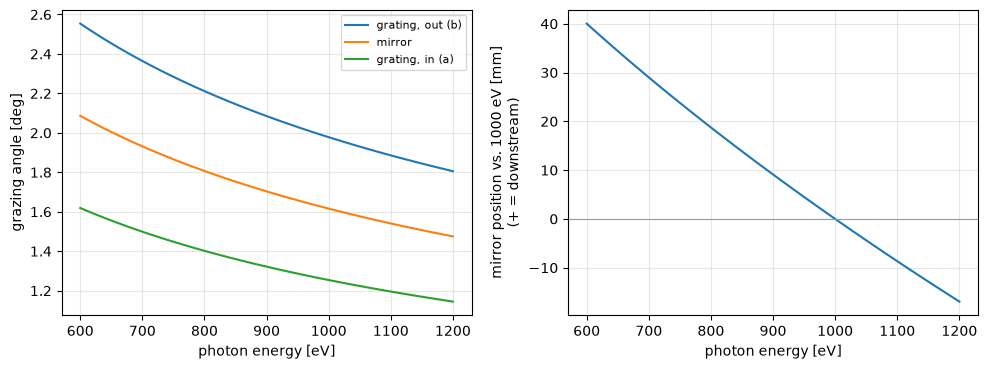

the mirror travels 57.0 mm along the beam over 600–1200 eV


In [9]:
band_eV = np.linspace(600.0, 1200.0, 60)
sols = [pgm_solve(E_eV) for E_eV in band_eV]

grazing_grating_in_deg  = [90 - np.degrees(s["alpha_rad"])  for s in sols]   # a = 90° − α
grazing_grating_out_deg = [90 - np.degrees(s["beta_rad"])   for s in sols]   # b = 90° − β
grazing_mirror_deg      = [90 - np.degrees(s["mirror_rad"]) for s in sols]
mirror_shift_mm = [(s["d_SM_m"] - sol["d_SM_m"]) * 1e3 for s in sols]        # relative to 1000 eV (sol, above)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(band_eV, grazing_grating_out_deg, label="grating, out (b)")
axes[0].plot(band_eV, grazing_mirror_deg, label="mirror")
axes[0].plot(band_eV, grazing_grating_in_deg, label="grating, in (a)")
axes[0].set_ylabel("grazing angle [deg]")
axes[0].legend(fontsize=8)
axes[1].plot(band_eV, mirror_shift_mm)
axes[1].axhline(0, color="0.6", lw=0.8)
axes[1].set_ylabel("mirror position vs. 1000 eV [mm]\n(+ = downstream)")
for ax in axes:
    ax.set_xlabel("photon energy [eV]")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"the mirror travels {max(mirror_shift_mm) - min(mirror_shift_mm):.1f} mm along the beam over 600–1200 eV")

# Away from 1000 eV there is nothing to compare against, so check the solve against its
# own two equations, with r the path the beam actually travels.
for E_eV in (600.0, 1200.0):
    s, wavelength_m = pgm_solve(E_eV), hc_eVm / E_eV
    path_r_m = s["d_SM_m"] + s["L_MG_m"]
    assert np.isclose(np.sin(s["alpha_rad"]) - np.sin(s["beta_rad"]), wavelength_m * g0_per_m, rtol=1e-9)
    assert np.isclose(np.cos(s["alpha_rad"])**2 / path_r_m + np.cos(s["beta_rad"])**2 / r_prime_m,
                      wavelength_m * g1_per_m2, rtol=1e-9)

### 3.3 Elements, trace, record

As before, each optic and its placement become an `...Element` with the beam arriving at it, and `trace_beam()` returns the beam leaving it. The mirror's output is the grating's input.

In [10]:
from shadow4.beamline.s4_beamline import S4Beamline
from shadow4.beamline.optical_elements.mirrors.s4_plane_mirror import S4PlaneMirrorElement
from shadow4.beamline.optical_elements.gratings.s4_plane_grating import S4PlaneGratingElement

beamline = S4Beamline()
beamline.set_light_source(light_source)

mirror_element = S4PlaneMirrorElement(optical_element=mirror, coordinates=mirror_coordinates,
                                      movements=None, input_beam=beam)
beam, mirror_footprint = mirror_element.trace_beam()
beamline.append_beamline_element(mirror_element)

grating_element = S4PlaneGratingElement(optical_element=grating, coordinates=grating_coordinates,
                                        movements=None, input_beam=beam)
beam, grating_footprint = grating_element.trace_beam()
beamline.append_beamline_element(grating_element)

print(beamline.distances_summary())

  ********  SUMMARY OF DISTANCES ********
   ** DISTANCES FOR ALL O.E. [m] **           
          OE         TYPE           p[m]           q[m]         src-oe     src-screen 
           1       MIRROR        24.1239         0.0887        24.1239        24.2126 
           2      GRATING         0.0887         7.5730        24.3013        31.8743 

   ** FOCUSING ELEMENTS **           
        OE                SHAPE      p_foc      q_foc        1/M 
         1                Plane          ?          ?          ? 

Sum of Alphas [deg]:         180.000 
Sum of Alphas Mod 180 [deg]: 0.000 
Sum of Alphas Mod 360 [deg]: 180.000 

Total deflection angle H =    -0.000000 rad =    -0.000 deg
Total deflection angle V =     0.000000 rad =     0.000 deg 



In [11]:
# The pasted `# main` ends with retrace(0.0). Tracing leaves y at ~1e-15 rather than
# exactly 0, and retrace(0) snaps it, so this line is needed for a bit-exact match.
beam.retrace(0.0)

assert np.array_equal(beam.rays, beam_paste.rays)
print("Rebuilt beam is identical to the pasted script's, ray for ray.")

Rebuilt beam is identical to the pasted script's, ray for ray.


Both optics deflect in the vertical plane, so after the grating **column 3 is lab vertical** — dispersive, and the direction the grating focuses — and **column 1 is lab horizontal**. The grating images the source, and a single real image is inverted, so **+column 3 points down**; `lab_frame()` flips it, and the rest of the notebook plots in the lab frame.

In [12]:
def rms(b, col):
    # rms of a Shadow column (numbered from 1) over good rays
    return b.rays[b.rays[:, 9] > 0, col - 1].std()

def centroid(b, col):
    return b.rays[b.rays[:, 9] > 0, col - 1].mean()

def lab_frame(b):
    # (lab horizontal, lab vertical up) positions of the good rays [m], for this beamline
    g = b.rays[:, 9] > 0
    return b.rays[g, 0], -b.rays[g, 2]

# Sanity check on the mapping: column 3 should be the vertical source demagnified by the
# grating, column 1 the horizontal source spread by its divergence over the full 31.874 m.
alpha_rad, beta_rad = grating_coordinates.angle_radial(), grating_coordinates.angle_radial_out()
magnification = r_prime_m * np.cos(alpha_rad) / (r_m * np.cos(beta_rad))
assert np.isclose(rms(beam, 3), 1.84e-5 * magnification, rtol=0.01)
assert np.isclose(rms(beam, 1), np.hypot(1.65e-5, 1.86e-5 * 31.874), rtol=0.005)
print(f"column 3 (lab vertical) {rms(beam, 3) * 1e6:.2f} µm rms, "
      f"column 1 (lab horizontal) {rms(beam, 1) * 1e6:.0f} µm rms")

column 3 (lab vertical) 3.64 µm rms, column 1 (lab horizontal) 593 µm rms


## 4. The Energy Axis

Every angle and distance in the export is set for 1000 eV. First we look at what the export does at another energy with its optics left alone (4.1), and then we put the energy back in: the source sizes as functions of energy (4.2), wired together with `pgm_solve()` from 3.2 into one beamline function (4.3), and looped over the grating's band (4.4).

### 4.1 The export at another energy

`trace_frozen()` is the 3.3 cell with the photon energy as its argument and every angle and distance left at the export's values — what you get by editing only the energy in the export.

600 eV is well inside this grating's band (552.9–1175.7 eV), so the grating can reach it. Here is what the frozen export makes of it.

In [13]:
def trace_frozen(energy_eV):
    # The export at a new photon energy: only the source line changes.
    # Mirror, grating and both placements are the 1000 eV objects from Section 3.
    src = SourceGeometrical(nrays=100000, seed=12)
    src.set_spatial_type_gaussian(sigma_h=1.65e-05, sigma_v=1.84e-05)
    src.set_depth_distribution_off()
    src.set_angular_distribution_gaussian(sigdix=1.86e-05, sigdiz=1.83e-05)
    src.set_energy_distribution_singleline(energy_eV, unit='eV')
    src.set_polarization(polarization_degree=1, phase_diff=0, coherent_beam=0)

    # source -> mirror -> grating, handing the beam from one element to the next
    b, _ = S4PlaneMirrorElement(optical_element=mirror, coordinates=mirror_coordinates,
                                movements=None, input_beam=src.get_beam()).trace_beam()
    b, _ = S4PlaneGratingElement(optical_element=grating, coordinates=grating_coordinates,
                                 movements=None, input_beam=b).trace_beam()
    b.retrace(0.0)   # onto the screen, as # main does
    return b

# At 1000 eV nothing has changed, so this must be the paste again.
assert np.array_equal(trace_frozen(1000.0).rays, beam.rays)

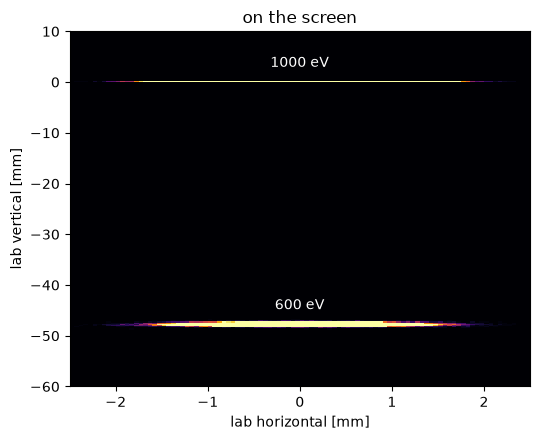

600 eV lands 47.77 mm below the axis (expected 47.77 mm)


In [14]:
b600 = trace_frozen(600.0)

h1000_m, v1000_m = lab_frame(beam)
h600_m, v600_m = lab_frame(b600)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.hist2d(np.r_[h1000_m, h600_m] * 1e3, np.r_[v1000_m, v600_m] * 1e3,
          bins=[100, 300], range=[[-2.5, 2.5], [-60, 10]], cmap="inferno", vmax=50)
ax.text(0, 3, "1000 eV", color="w", ha="center")
ax.text(0, v600_m.mean() * 1e3 + 3, "600 eV", color="w", ha="center")
ax.set_xlabel("lab horizontal [mm]")
ax.set_ylabel("lab vertical [mm]")
ax.set_title("on the screen")
plt.tight_layout()
plt.show()

# Hand estimate: at the frozen α, the grating equation sends 600 eV to a different β.
alpha_rad, beta_rad = grating_coordinates.angle_radial(), grating_coordinates.angle_radial_out()
wavelength_600_m = hc_eVm / 600.0
beta_600_rad = np.arcsin(np.sin(alpha_rad) - wavelength_600_m * g0_per_m)
drop_expected_m = r_prime_m * (beta_rad - beta_600_rad)

print(f"600 eV lands {-v600_m.mean() * 1e3:.2f} mm below the axis (expected {drop_expected_m * 1e3:.2f} mm)")
assert np.isclose(-v600_m.mean(), drop_expected_m, rtol=0.01)

The beam has moved, which is what a grating does with a different wavelength. It is also 209 µm tall against 3.6 µm at 1000 eV — so the focus has moved too. Where to?

Solve the focus condition for the distance instead of the angles:

$$r'_\text{focus} = \frac{\cos^2\beta_{600}}{\lambda_{600}\, g_1 - \cos^2\alpha / r}$$

and `retrace` can go and look.

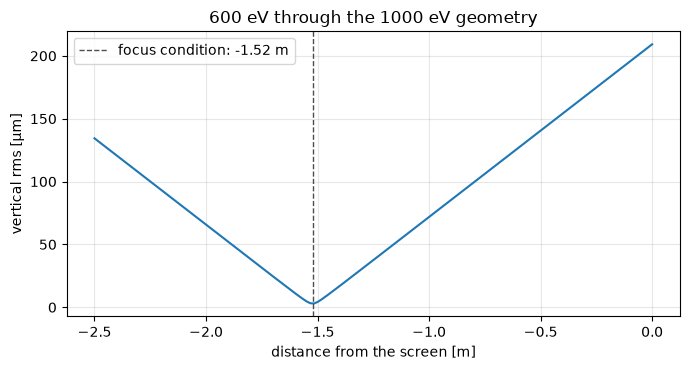

waist at -1.517 m, rms 3.0 µm   (focus condition: -1.521 m)


In [15]:
r_focus_m = np.cos(beta_600_rad)**2 / (wavelength_600_m * g1_per_m2 - np.cos(alpha_rad)**2 / r_m)

# Step the observation plane upstream of the screen; the rays are already traced,
# so each plane is a retrace (milliseconds), not a new trace.
dz_list_m = np.linspace(-2.5, 0.0, 151)
rms_dz_m = []
for dz_m in dz_list_m:
    b = b600.duplicate()      # retrace overwrites the rays
    b.retrace(dz_m)
    rms_dz_m.append(rms(b, 3))
rms_dz_m = np.array(rms_dz_m)
waist_m = dz_list_m[np.argmin(rms_dz_m)]   # plane of smallest vertical size

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(dz_list_m, rms_dz_m * 1e6, "-")
ax.axvline(r_focus_m - r_prime_m, color="0.3", ls="--", lw=1, label=f"focus condition: {r_focus_m - r_prime_m:.2f} m")
ax.set_xlabel("distance from the screen [m]")
ax.set_ylabel("vertical rms [µm]")
ax.set_title("600 eV through the 1000 eV geometry")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"waist at {waist_m:.3f} m, rms {rms_dz_m.min() * 1e6:.1f} µm   (focus condition: {r_focus_m - r_prime_m:.3f} m)")
assert abs(waist_m - (r_focus_m - r_prime_m)) <= dz_list_m[1] - dz_list_m[0]

It did move: 1.5 m upstream of the screen. And there, is the beam any good?

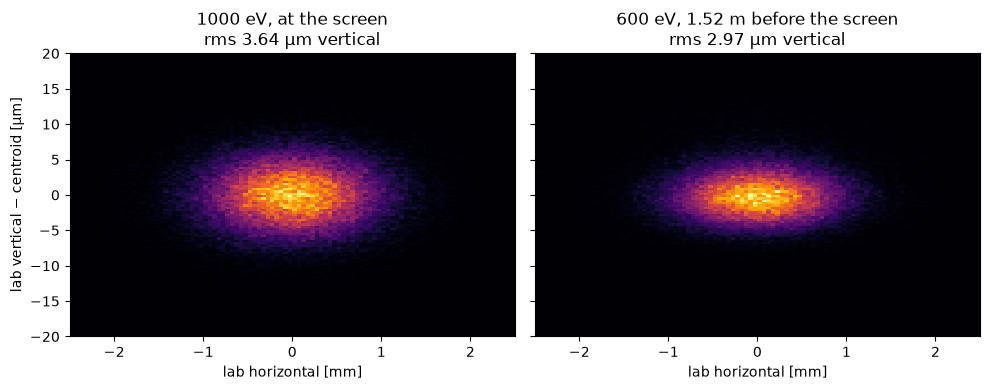

In [16]:
b600_at_focus = b600.duplicate()
b600_at_focus.retrace(waist_m)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, b, label in [(axes[0], beam, "1000 eV, at the screen"),
                     (axes[1], b600_at_focus, f"600 eV, {-waist_m:.2f} m before the screen")]:
    h_m, v_m = lab_frame(b)
    ax.hist2d(h_m * 1e3, (v_m - v_m.mean()) * 1e6, bins=[100, 120],
              range=[[-2.5, 2.5], [-20, 20]], cmap="inferno")
    ax.set_title(f"{label}\nrms {v_m.std() * 1e6:.2f} µm vertical")
    ax.set_xlabel("lab horizontal [mm]")
axes[0].set_ylabel("lab vertical − centroid [µm]")
plt.tight_layout()
plt.show()

So nothing is broken: at 600 eV the grating still makes a good focus, 1.5 m short of the screen and 48 mm off the axis. But an exit slit is a fixed hole in a fixed wall. To put every energy through it, the angles **and** the distances have to follow the energy — which is what `pgm_solve()` (3.2) computes, and what the rest of Section 4 wires in.

### 4.2 `source_sizes()` — the undulator source vs. energy

The photon source is the electron beam and the single-electron undulator emission, added in quadrature:

$$\Sigma = \sqrt{\sigma_e^2 + \sigma_r^2}, \qquad \Sigma' = \sqrt{\sigma_e'^2 + \sigma_r'^2}$$

| | size | divergence | depends on photon energy |
|---|---|---|---|
| electron beam: emittance $\varepsilon$, beta function $\beta_{x,y}$ | $\sqrt{\varepsilon\,\beta}$ | $\sqrt{\varepsilon/\beta}$ | no |
| undulator emission, length $L_u$ | $\dfrac{\sqrt{2\lambda L_u}}{2\pi}$ | $\sqrt{\dfrac{\lambda}{2L_u}}$ | yes |

ALS-U: $\varepsilon$ = 71 pm in both planes, $\beta_x$ = 2.05 m, $\beta_y$ = 3.0 m. COSMIC-U's undulator: $L_u$ = 2 m.

In [17]:
def source_sizes(energy_eV):
    # rms size [m] and divergence [rad] of the photon source, horizontal and vertical
    wavelength_m = hc_eVm / energy_eV
    emittance_m, beta_x_m, beta_y_m, undulator_m = 71e-12, 2.05, 3.0, 2.0

    photon_size_m = np.sqrt(2 * wavelength_m * undulator_m) / (2 * np.pi)
    photon_div_rad = np.sqrt(wavelength_m / (2 * undulator_m))

    return {"sigma_h_m": np.hypot(np.sqrt(emittance_m * beta_x_m), photon_size_m),
            "sigma_v_m": np.hypot(np.sqrt(emittance_m * beta_y_m), photon_size_m),
            "div_h_rad": np.hypot(np.sqrt(emittance_m / beta_x_m), photon_div_rad),
            "div_v_rad": np.hypot(np.sqrt(emittance_m / beta_y_m), photon_div_rad)}

At 1000 eV it must give the four numbers the export typed in, to the digits it typed.

In [18]:
export_source = {"sigma_h_m": 1.65e-05, "sigma_v_m": 1.84e-05, "div_h_rad": 1.86e-05, "div_v_rad": 1.83e-05}

for E_eV in (600.0, 1000.0, 1200.0):
    s = source_sizes(E_eV)
    print(f"{E_eV:6.1f} eV   size h, v {s['sigma_h_m'] * 1e6:5.2f}, {s['sigma_v_m'] * 1e6:5.2f} µm   "
          f"divergence h, v {s['div_h_rad'] * 1e6:5.2f}, {s['div_v_rad'] * 1e6:5.2f} µrad")

s1000 = source_sizes(1000.0)
for key, value in export_source.items():
    assert round(s1000[key] * 1e6, 1) == round(value * 1e6, 1), key   # the export keeps three digits

 600.0 eV   size h, v 18.84, 20.55 µm   divergence h, v 23.48, 23.24 µrad
1000.0 eV   size h, v 16.47, 18.40 µm   divergence h, v 18.56, 18.27 µrad
1200.0 eV   size h, v 15.82, 17.82 µm   divergence h, v 17.12, 16.79 µrad


Both terms matter here: the electron beam sets the floor, and the undulator term — the only energy-dependent part — grows toward the low end, so both the size and the divergence change across the band.

### 4.3 `run_beamline(energy_eV)`

The export's `run_beamline()`, with the energy as its argument. Source from `source_sizes()`, both optics placed from `pgm_solve()`; the optics themselves, the apertures and the azimuths are the export's.

It comes in two halves, so each can be checked on its own:

- `trace(energy_eV, source, geometry)` — builds and traces from numbers it is given;
- `run_beamline(energy_eV)` — computes those numbers, then calls `trace`.

In [19]:
def trace(energy_eV, source, geometry, nrays=100000, seed=12):
    # --- source: the export's block, with the four numbers from `source`
    light_source = SourceGeometrical(nrays=nrays, seed=seed)
    light_source.set_spatial_type_gaussian(sigma_h=source["sigma_h_m"], sigma_v=source["sigma_v_m"])
    light_source.set_depth_distribution_off()
    light_source.set_angular_distribution_gaussian(sigdix=source["div_h_rad"], sigdiz=source["div_v_rad"])
    light_source.set_energy_distribution_singleline(energy_eV, unit='eV')
    light_source.set_polarization(polarization_degree=1, phase_diff=0, coherent_beam=0)
    b = light_source.get_beam()

    # --- plane mirror (3.2): p = d_SM, q = first half of L_MG
    half_gap_m = geometry["L_MG_m"] / 2
    coords = ElementCoordinates(p=geometry["d_SM_m"], q=half_gap_m, angle_azimuthal=0,
                                angle_radial=geometry["mirror_rad"], angle_radial_out=geometry["mirror_rad"])
    b, _ = S4PlaneMirrorElement(optical_element=mirror, coordinates=coords, movements=None, input_beam=b).trace_beam()

    # --- VLS grating (3.2): p = second half of L_MG, q = r'
    coords = ElementCoordinates(p=half_gap_m, q=r_prime_m, angle_azimuthal=3.141592654,
                                angle_radial=geometry["alpha_rad"], angle_radial_out=geometry["beta_rad"])
    b, footprint = S4PlaneGratingElement(optical_element=grating, coordinates=coords, movements=None, input_beam=b).trace_beam()

    b.retrace(0.0)   # onto the screen, as # main does
    return b, footprint


def run_beamline(energy_eV, nrays=100000, seed=12):
    return trace(energy_eV, source_sizes(energy_eV), pgm_solve(energy_eV), nrays=nrays, seed=seed)

**Check at 1000 eV, in two steps.** Given the export's own numbers, `trace()` must reproduce the paste ray for ray — that checks the wiring. `run_beamline(1000)` then differs only by the export's rounding, so its image must agree to a fraction of a percent.

In [20]:
# The export's numbers, as typed. The mirror-grating gap is written as two halves of
# 0.0886895 m in the export, so L_MG is their sum; halving it again gives them back exactly.
export_geometry = {"alpha_rad": 1.548912027, "beta_rad": 1.536274133, "mirror_rad": 1.54259308,
                   "d_SM_m": 24.123903, "L_MG_m": 2 * 0.0886895}

b_wired, _ = trace(1000.0, export_source, export_geometry)
assert np.array_equal(b_wired.rays, beam_paste.rays)
print("trace() with the export's numbers: identical to the paste, ray for ray")

b_solved, _ = run_beamline(1000.0)
for col, name in [(1, "horizontal"), (3, "vertical")]:
    print(f"{name:10s} rms  paste {rms(beam_paste, col) * 1e6:8.3f} µm   run_beamline {rms(b_solved, col) * 1e6:8.3f} µm")
    assert np.isclose(rms(b_solved, col), rms(beam_paste, col), rtol=0.005)
assert abs(centroid(b_solved, 3)) < 0.1e-6   # still on axis

trace() with the export's numbers: identical to the paste, ray for ray


horizontal rms  paste  593.276 µm   run_beamline  592.104 µm
vertical   rms  paste    3.641 µm   run_beamline    3.641 µm


**And at 600 eV**, where the frozen export missed by 48 mm:

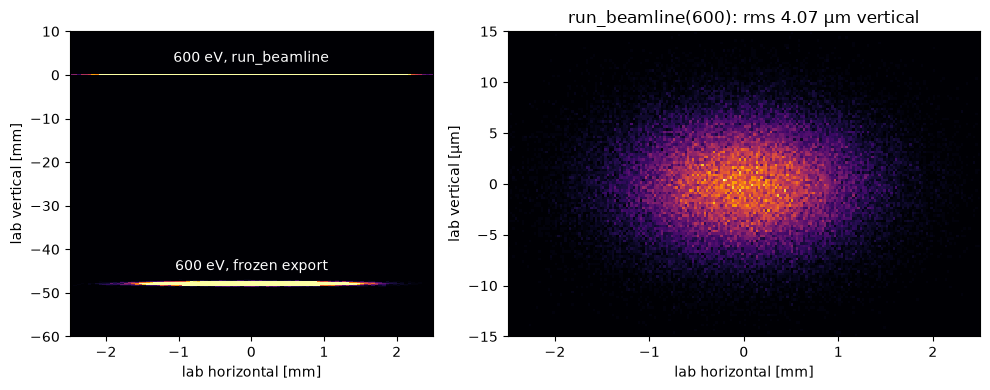

centroid -0.023 µm   rms 4.07 µm   (expected 4.06 µm)


In [21]:
b600_solved, _ = run_beamline(600.0)
h_m, v_m = lab_frame(b600_solved)

# Hand estimate of the image size: vertical source × grating magnification, both at 600 eV
s600, g600 = source_sizes(600.0), pgm_solve(600.0)
magnification_600 = r_prime_m * np.cos(g600["alpha_rad"]) / (r_m * np.cos(g600["beta_rad"]))
expected_600_m = s600["sigma_v_m"] * magnification_600

# Left: frozen vs solved on the screen. Right: the solved beam, zoomed.
fig, axes = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={"width_ratios": [1, 1.3]})
axes[0].hist2d(np.r_[h600_m, h_m] * 1e3, np.r_[v600_m, v_m] * 1e3, bins=[100, 300],
               range=[[-2.5, 2.5], [-60, 10]], cmap="inferno", vmax=50)
axes[0].text(0, 3, "600 eV, run_beamline", color="w", ha="center")
axes[0].text(0, v600_m.mean() * 1e3 + 3, "600 eV, frozen export", color="w", ha="center")
axes[0].set_ylabel("lab vertical [mm]")
axes[1].hist2d(h_m * 1e3, v_m * 1e6, bins=[200, 120], range=[[-2.5, 2.5], [-15, 15]], cmap="inferno")
axes[1].set_ylabel("lab vertical [µm]")
axes[1].set_title(f"run_beamline(600): rms {v_m.std() * 1e6:.2f} µm vertical")
for ax in axes:
    ax.set_xlabel("lab horizontal [mm]")
plt.tight_layout()
plt.show()

print(f"centroid {v_m.mean() * 1e6:+.3f} µm   rms {v_m.std() * 1e6:.2f} µm   (expected {expected_600_m * 1e6:.2f} µm)")
assert abs(v_m.mean()) < 0.1e-6
assert np.isclose(v_m.std(), expected_600_m, rtol=0.02)

### 4.4 Scan across the grating's band

## Appendix — where the ruling comes from

This notebook takes the ruling $g_0 \dots g_3$ as given and solves for the angles. The *VLS Grating coeff calc* widget runs the other way, once, when the grating is designed:

| | given | solved for |
|---|---|---|
| **design time** (the widget, once) | $g_0$, $r$, $r'$, a design energy (806 eV) and a value of $c_{ff}$ | the design angles $\alpha_d$, $\beta_d$, and from them $g_1$, $g_2$, $g_3$ |
| **run time** (this notebook, every energy) | $g_0$, $g_1$, $r$, $r'$, the photon energy | $\alpha$, $\beta$ |

$c_{ff} = \cos\beta / \cos\alpha$ is the ratio of the grazing angles — one number that fixes the grating's working point. It is the designer's knob: a larger $c_{ff}$ means a shallower incidence, higher resolving power and lower flux. It is an input exactly once, at design time; after that the ruling is cut into glass and the angles follow from it.

The three correction coefficients come from the optical path across the grating, expanded in the coordinate $w$ along its length and evaluated at the design angles:

$$\lambda_d g_1 = \frac{\cos^2\alpha_d}{r} + \frac{\cos^2\beta_d}{r'} \qquad (w^2: \text{defocus})$$

$$\lambda_d g_2 = \frac{3}{2}\left[\frac{\sin\beta_d\cos^2\beta_d}{r'^2} - \frac{\sin\alpha_d\cos^2\alpha_d}{r^2}\right] \qquad (w^3: \text{coma})$$

$$\lambda_d g_3 = \frac{1}{2}\left[\frac{\cos^2\alpha_d\,(4\sin^2\alpha_d - \cos^2\alpha_d)}{r^3} + \frac{\cos^2\beta_d\,(4\sin^2\beta_d - \cos^2\beta_d)}{r'^3}\right] \qquad (w^4: \text{spherical})$$

$g_1$ is special: it kills defocus at *every* energy, provided the angles obey the focus condition — that is what 3.2 solves. $g_2$ and $g_3$ are evaluated once, at the design angles, so coma and spherical aberration are cancelled exactly at 806 eV and only approximately elsewhere.

In [22]:
design_energy_eV, cff_design = 806.0, 1.5772
wavelength_design_m = hc_eVm / design_energy_eV

# Design-time solve: the grating equation, with cos β = c_ff cos α instead of the focus condition.
def cff_residual(a_rad):
    b_rad = np.arcsin(np.sin(a_rad) - wavelength_design_m * g0_per_m)
    return np.cos(b_rad) - cff_design * np.cos(a_rad)

alpha_design_rad = brentq(cff_residual, 0.0, np.radians(89.9999), xtol=1e-15)
beta_design_rad = np.arcsin(np.sin(alpha_design_rad) - wavelength_design_m * g0_per_m)

ca, cb = np.cos(alpha_design_rad), np.cos(beta_design_rad)
sa, sb = np.sin(alpha_design_rad), np.sin(beta_design_rad)
g1 = (ca**2 / r_m + cb**2 / r_prime_m) / wavelength_design_m
g2 = 1.5 * (sb * cb**2 / r_prime_m**2 - sa * ca**2 / r_m**2) / wavelength_design_m
g3 = 0.5 * (ca**2 * (4 * sa**2 - ca**2) / r_m**3
            + cb**2 * (4 * sb**2 - cb**2) / r_prime_m**3) / wavelength_design_m

print(f"design angles: α {np.degrees(alpha_design_rad):.6f}°   β {np.degrees(beta_design_rad):.6f}°"
      f"   (widget Design Output: 88.603245°, 87.796714°)")
print(f"g1 {g1:12.3f}   g2 {g2:11.3f}   g3 {g3:10.3f}")
print(f"grating:   {grating._ruling_coeff_linear:12.3f}   {grating._ruling_coeff_quadratic:11.3f}   {grating._ruling_coeff_cubic:10.3f}")

assert np.isclose(g1, g1_per_m2, rtol=1e-7)
assert np.isclose(g2, 24131.408, rtol=1e-7)
assert np.isclose(g3, 4470.25, rtol=1e-6)

design angles: α 88.603245°   β 87.796714°   (widget Design Output: 88.603245°, 87.796714°)
g1   142771.836   g2   24131.408   g3   4470.250
grating:     142771.836     24131.408     4470.250


The ruling in the export's grating block, reproduced from four numbers and a design energy. And $c_{ff}$, the input here, is only a diagnostic at run time: the focus condition in 3.2 keeps it at 1.5770–1.5774 across the band without ever being told to.